# Lab 0: Introduction to PyTorch

**Goal:** Get comfortable with PyTorch — the framework we'll use to build every GAN in this course.

**What you'll learn:**
- Tensors: PyTorch's building blocks (like NumPy arrays, but with superpowers)
- Automatic gradients: the magic behind `loss.backward()`
- `nn.Sequential`: build neural networks in a few lines
- The 3-line training loop that powers everything
- Loss functions and optimizers
- GPU acceleration: how to use your GPU

**Time:** ~45 minutes

---

## Part 1: Setup and Installation

In [2]:
# If you don't have PyTorch installed, uncomment and run:
# !pip install torch torchvision matplotlib

import torch
import torch.nn as nn
import matplotlib.pyplot as plt

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available:  {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU:             {torch.cuda.get_device_name(0)}")

PyTorch version: 2.12.1+cpu
CUDA available:  False


---
## Part 2: Tensors — The Building Blocks

Everything in PyTorch is a **tensor**. Think of it like a NumPy array:

| NumPy | PyTorch |
|---|---|
| `np.array([1,2,3])` | `torch.tensor([1,2,3])` |
| `np.zeros(3)` | `torch.zeros(3)` |
| `a @ b` | `a @ b` |

So why switch? **Automatic gradients** and **GPU acceleration**.

In [3]:
# Creating tensors
a = torch.tensor([1.0, 2.0, 3.0])
b = torch.tensor([4.0, 5.0, 6.0])

print("Basics:")
print(f"  a = {a}")
print(f"  b = {b}")
print(f"  a + b = {a + b}")
print(f"  a * b = {a * b}       (element-wise)")
print(f"  a @ b = {a @ b}           (dot product: 1*4 + 2*5 + 3*6 = 32)")

Basics:
  a = tensor([1., 2., 3.])
  b = tensor([4., 5., 6.])
  a + b = tensor([5., 7., 9.])
  a * b = tensor([ 4., 10., 18.])       (element-wise)
  a @ b = 32.0           (dot product: 1*4 + 2*5 + 3*6 = 32)


In [4]:
# Common tensor creation functions
print("Creating tensors:")
print(f"  zeros:   {torch.zeros(4)}")
print(f"  ones:    {torch.ones(4)}")
print(f"  random:  {torch.randn(4)}         (normal distribution)")
print(f"  range:   {torch.arange(0, 10, 2)}")

Creating tensors:
  zeros:   tensor([0., 0., 0., 0.])
  ones:    tensor([1., 1., 1., 1.])
  random:  tensor([ 0.4639, -1.1876, -0.1038, -1.7380])         (normal distribution)
  range:   tensor([0, 2, 4, 6, 8])


In [5]:
# Tensor shapes -- crucial for neural networks
scalar = torch.tensor(5.0)                    # 0D: single number
vector = torch.tensor([1.0, 2.0, 3.0])       # 1D: list of numbers
matrix = torch.tensor([[1, 2], [3, 4], [5, 6]])  # 2D: table
image  = torch.randn(1, 28, 28)              # 3D: 1 channel, 28x28
batch  = torch.randn(64, 1, 28, 28)          # 4D: 64 images

print("Shapes:")
print(f"  scalar: {scalar.shape}      (0D)")
print(f"  vector: {vector.shape}   (1D)")
print(f"  matrix: {matrix.shape}   (2D: 3 rows, 2 cols)")
print(f"  image:  {image.shape}  (3D: 1 channel, 28x28 pixels)")
print(f"  batch:  {batch.shape}  (4D: 64 images, each 1x28x28)")

Shapes:
  scalar: torch.Size([])      (0D)
  vector: torch.Size([3])   (1D)
  matrix: torch.Size([3, 2])   (2D: 3 rows, 2 cols)
  image:  torch.Size([1, 28, 28])  (3D: 1 channel, 28x28 pixels)
  batch:  torch.Size([64, 1, 28, 28])  (4D: 64 images, each 1x28x28)


In [6]:
# Reshaping -- you'll do this a LOT in GANs
x = torch.arange(12.0)    # [0, 1, 2, ... 11]
print(f"Original: {x.shape} -> {x}")

# Reshape to 3x4 matrix
m = x.view(3, 4)
print(f"\nview(3,4): {m.shape}")
print(m)

# Reshape to 2x2x3
t = x.view(2, 2, 3)
print(f"\nview(2,2,3): {t.shape}")
print(t)

# Flatten back to 1D (-1 means "figure it out")
flat = t.view(-1)
print(f"\nview(-1): {flat.shape} -> {flat}")

print("\n.view() and .reshape() are your best friends in GANs.")
print("You'll flatten 28x28 images to 784, and reshape 784 back to 28x28.")

Original: torch.Size([12]) -> tensor([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11.])

view(3,4): torch.Size([3, 4])
tensor([[ 0.,  1.,  2.,  3.],
        [ 4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11.]])

view(2,2,3): torch.Size([2, 2, 3])
tensor([[[ 0.,  1.,  2.],
         [ 3.,  4.,  5.]],

        [[ 6.,  7.,  8.],
         [ 9., 10., 11.]]])

view(-1): torch.Size([12]) -> tensor([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11.])

.view() and .reshape() are your best friends in GANs.
You'll flatten 28x28 images to 784, and reshape 784 back to 28x28.


---
## Part 3: The Superpower — Automatic Gradients

This is **THE reason** we use PyTorch.

In Lessons 1-11, you calculated gradients by hand. For a simple neuron, that's fine.
For a network with millions of weights? Impossible by hand.

PyTorch calculates **ALL gradients automatically** with one line: `loss.backward()`

In [7]:
# A single neuron: y = w * x
# We want w such that y = target

w = torch.tensor(1.0, requires_grad=True)   # <-- tells PyTorch: track gradients for this!
x = torch.tensor(2.0)
target = torch.tensor(4.0)

# Forward pass
prediction = w * x
loss = (prediction - target) ** 2

print(f"w = {w.item():.1f}")
print(f"prediction = w * x = {w.item():.1f} * {x.item():.1f} = {prediction.item():.1f}")
print(f"target = {target.item():.1f}")
print(f"loss = (pred - target)^2 = ({prediction.item():.1f} - {target.item():.1f})^2 = {loss.item():.1f}")

# Backward pass -- ONE LINE!
loss.backward()

print(f"\ngradient of w = {w.grad.item():.1f}")
print(f"\nBy hand: d(loss)/dw = 2*(w*x - target)*x = 2*(2-4)*2 = -8.0")
print(f"PyTorch: {w.grad.item():.1f}   <-- same answer, zero manual math!")

w = 1.0
prediction = w * x = 1.0 * 2.0 = 2.0
target = 4.0
loss = (pred - target)^2 = (2.0 - 4.0)^2 = 4.0

gradient of w = -8.0

By hand: d(loss)/dw = 2*(w*x - target)*x = 2*(2-4)*2 = -8.0
PyTorch: -8.0   <-- same answer, zero manual math!


In [8]:
# More complex: y = w1 * x^2 + w2 * x + b
# PyTorch handles ANY computation, no matter how complex

w1 = torch.tensor(1.0, requires_grad=True)
w2 = torch.tensor(1.0, requires_grad=True)
b  = torch.tensor(0.0, requires_grad=True)

x = torch.tensor(3.0)
target = torch.tensor(10.0)

y = w1 * x**2 + w2 * x + b
loss = (y - target) ** 2
loss.backward()

print("Gradients for y = w1*x^2 + w2*x + b:")
print(f"  d(loss)/d(w1) = {w1.grad.item():.1f}")
print(f"  d(loss)/d(w2) = {w2.grad.item():.1f}")
print(f"  d(loss)/d(b)  = {b.grad.item():.1f}")

print(f"\nPyTorch tracked ALL operations and computed ALL gradients.")
print(f"For a network with 1 million weights, it does the same thing.")

Gradients for y = w1*x^2 + w2*x + b:
  d(loss)/d(w1) = 36.0
  d(loss)/d(w2) = 12.0
  d(loss)/d(b)  = 4.0

PyTorch tracked ALL operations and computed ALL gradients.
For a network with 1 million weights, it does the same thing.


### How it works: the computation graph

Every operation you do on a tensor with `requires_grad=True` gets recorded:

```
w ---> [*] ---> prediction ---> [-] ---> [^2] ---> loss
x -----^        target ---------^
```

When you call `loss.backward()`, PyTorch walks this graph **backwards** and computes every gradient. That's backpropagation — automated.

---
## Part 4: Training a Neuron with PyTorch

Let's train a single neuron to learn `y = 3x`. Same as Lesson 5, but with PyTorch.

In [9]:
# Training data: y = 3x
X = torch.tensor([1.0, 2.0, 3.0, 4.0, 5.0])
Y = torch.tensor([3.0, 6.0, 9.0, 12.0, 15.0])

# Our learnable weight
w = torch.tensor(0.5, requires_grad=True)

learning_rate = 0.01
losses = []

for epoch in range(1, 101):
    # Forward pass
    predictions = w * X
    loss = ((predictions - Y) ** 2).mean()   # MSE loss

    # Backward pass
    loss.backward()

    # Update weight (manually for now)
    with torch.no_grad():                     # don't track this operation
        w -= learning_rate * w.grad
        w.grad.zero_()                        # clear gradient for next iteration

    losses.append(loss.item())

    if epoch in [1, 10, 25, 50, 100]:
        print(f"Epoch {epoch:3d}: w = {w.item():.4f}  loss = {loss.item():.6f}")

print(f"\nFinal w = {w.item():.4f} (target: 3.0)")

Epoch   1: w = 1.0500  loss = 68.750000
Epoch  10: w = 2.7916  loss = 0.785192
Epoch  25: w = 2.9950  loss = 0.000455
Epoch  50: w = 3.0000  loss = 0.000000
Epoch 100: w = 3.0000  loss = 0.000000

Final w = 3.0000 (target: 3.0)


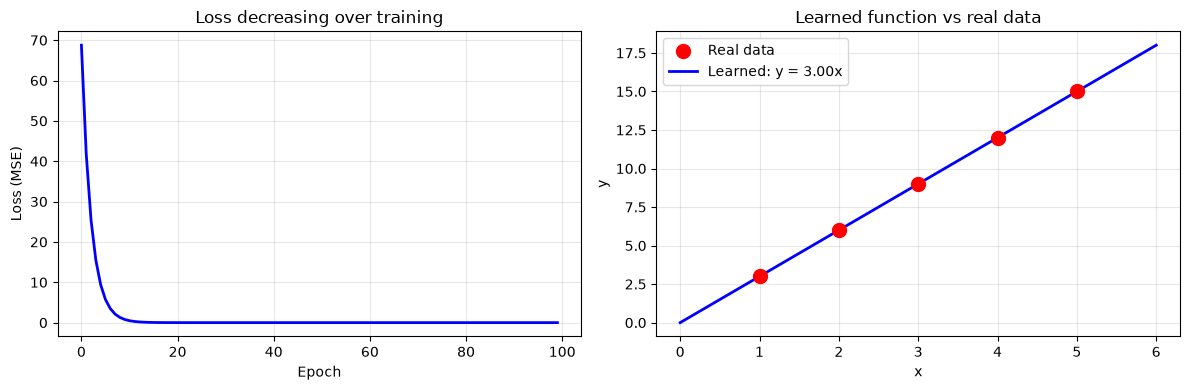

In [10]:
# Visualize training
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(losses, color='blue', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].set_title('Loss decreasing over training')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(X.numpy(), Y.numpy(), color='red', s=100, label='Real data', zorder=5)
x_line = torch.linspace(0, 6, 100)
axes[1].plot(x_line.numpy(), (w.item() * x_line).numpy(), 'b-',
             linewidth=2, label=f'Learned: y = {w.item():.2f}x')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].set_title('Learned function vs real data')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Part 5: nn.Sequential — Build Networks in Seconds

PyTorch has **ready-made building blocks**. Stack them with `nn.Sequential`:

| Building block | What it does | From which lesson? |
|---|---|---|
| `nn.Linear(in, out)` | `y = Wx + b` | Lesson 1 |
| `nn.ReLU()` | `max(0, z)` | Lesson 9 |
| `nn.Sigmoid()` | `1 / (1 + e^-z)` | Lesson 12 |
| `nn.LeakyReLU(0.2)` | `max(0.2z, z)` | Used in GANs |
| `nn.Tanh()` | Output in [-1, 1] | Used in GANs |

In [27]:
# Build a classifier: 1 input --> 4 hidden --> 1 output
model = nn.Sequential(
    nn.Linear(1, 4),     # 1 input -> 4 hidden neurons
    nn.ReLU(),           # activation
    nn.Linear(4, 1),     # 4 hidden -> 1 output
    nn.Sigmoid()         # squash to [0, 1] probability
)

print("Model architecture:")
print(model)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params}")
print("\nParameter breakdown:")
for name, param in model.named_parameters():
    print(f"  {name}: shape={list(param.shape)}, count={param.numel()}")

Model architecture:
Sequential(
  (0): Linear(in_features=1, out_features=4, bias=True)
  (1): ReLU()
  (2): Linear(in_features=4, out_features=1, bias=True)
  (3): Sigmoid()
)

Total parameters: 13

Parameter breakdown:
  0.weight: shape=[4, 1], count=4
  0.bias: shape=[4], count=4
  2.weight: shape=[1, 4], count=4
  2.bias: shape=[1], count=1


In [12]:
# Forward pass: just call the model!
x = torch.tensor([[2.0]])
output = model(x)
print(f"Input:  {x.item()}")
print(f"Output: {output.item():.4f}")
print(f"\nOne line. PyTorch did: Linear -> ReLU -> Linear -> Sigmoid")

Input:  2.0
Output: 0.5424

One line. PyTorch did: Linear -> ReLU -> Linear -> Sigmoid


### Visualize the activations

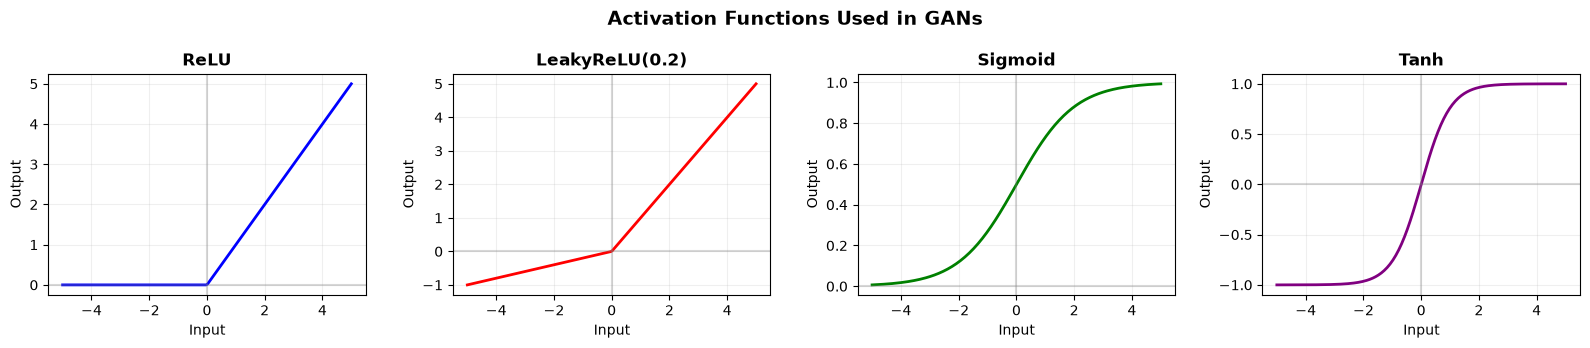

Where each is used:
  ReLU:         Generator hidden layers
  LeakyReLU:    Discriminator hidden layers (lets small negatives through)
  Sigmoid:      Discriminator output (probability 0-1)
  Tanh:         Generator output (pixel values -1 to 1)


In [28]:
# See all 5 activations side by side
x = torch.linspace(-5, 5, 200)

activations = {
    'ReLU': nn.ReLU()(x),
    'LeakyReLU(0.2)': nn.LeakyReLU(0.2)(x),
    'Sigmoid': torch.sigmoid(x),
    'Tanh': torch.tanh(x),
}

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
colors = ['blue', 'red', 'green', 'purple']

for ax, (name, y), color in zip(axes, activations.items(), colors):
    ax.plot(x.numpy(), y.detach().numpy(), color=color, linewidth=2)
    ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
    ax.axvline(x=0, color='gray', linestyle='-', alpha=0.3)
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Input')
    ax.set_ylabel('Output')
    ax.grid(True, alpha=0.2)

plt.suptitle('Activation Functions Used in GANs', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Where each is used:")
print("  ReLU:         Generator hidden layers")
print("  LeakyReLU:    Discriminator hidden layers (lets small negatives through)")
print("  Sigmoid:      Discriminator output (probability 0-1)")
print("  Tanh:         Generator output (pixel values -1 to 1)")

---
## Part 6: Loss Functions and Optimizers

### Loss functions — how wrong is the prediction?

In [14]:
# MSE Loss: for regression (predict a number)
mse = nn.MSELoss()
prediction = torch.tensor([2.5])
target = torch.tensor([3.0])
print(f"MSE Loss: prediction={prediction.item()}, target={target.item()} "
      f"--> loss={mse(prediction, target).item():.4f}")

# BCE Loss: for classification (predict real/fake) -- THIS IS WHAT GANs USE
bce = nn.BCELoss()
prediction = torch.tensor([0.8])    # model says 80% "real"
target = torch.tensor([1.0])        # actual label: real
print(f"BCE Loss: prediction={prediction.item()}, target={target.item()} "
      f"--> loss={bce(prediction, target).item():.4f}")

prediction = torch.tensor([0.8])    # model says 80% "real"
target = torch.tensor([0.0])        # actual label: fake!
print(f"BCE Loss: prediction={prediction.item()}, target={target.item()} "
      f"--> loss={bce(prediction, target).item():.4f}  (high! wrong prediction)")

MSE Loss: prediction=2.5, target=3.0 --> loss=0.2500
BCE Loss: prediction=0.800000011920929, target=1.0 --> loss=0.2231
BCE Loss: prediction=0.800000011920929, target=0.0 --> loss=1.6094  (high! wrong prediction)


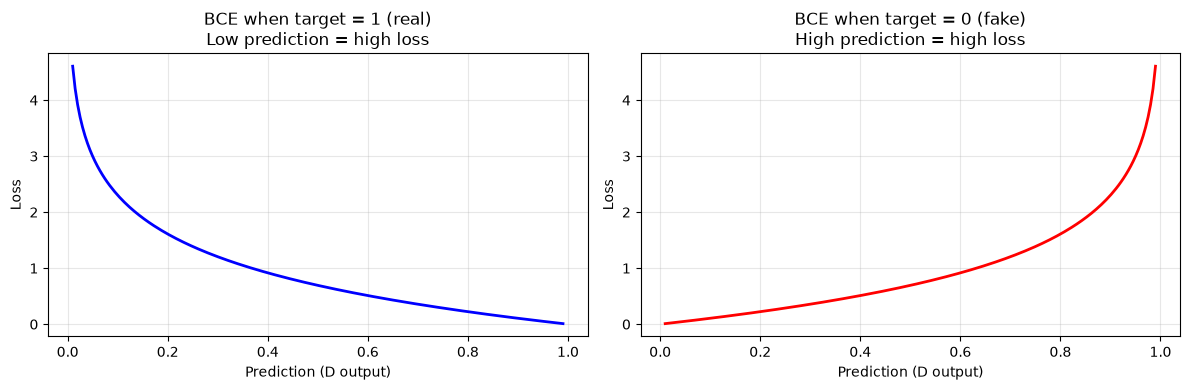

BCE Loss punishes wrong predictions exponentially.
This is what the Discriminator uses to learn real vs fake.


In [29]:
# Visualize BCE Loss
p = torch.linspace(0.01, 0.99, 200)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# When target = 1 (real)
bce_real = -torch.log(p)
axes[0].plot(p.numpy(), bce_real.numpy(), 'b-', linewidth=2)
axes[0].set_xlabel('Prediction (D output)')
axes[0].set_ylabel('Loss')
axes[0].set_title('BCE when target = 1 (real)\nLow prediction = high loss')
axes[0].grid(True, alpha=0.3)

# When target = 0 (fake)
bce_fake = -torch.log(1 - p)
axes[1].plot(p.numpy(), bce_fake.numpy(), 'r-', linewidth=2)
axes[1].set_xlabel('Prediction (D output)')
axes[1].set_ylabel('Loss')
axes[1].set_title('BCE when target = 0 (fake)\nHigh prediction = high loss')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


print("BCE Loss punishes wrong predictions exponentially.")
print("This is what the Discriminator uses to learn real vs fake.")

### Optimizers — how to update weights

In [31]:
# SGD: simple, takes fixed-size steps
# Adam: adaptive, takes smarter steps (preferred for GANs)

model_sgd = nn.Sequential(nn.Linear(1, 4), nn.ReLU(), nn.Linear(4, 1), nn.Sigmoid())
model_adam = nn.Sequential(nn.Linear(1, 4), nn.ReLU(), nn.Linear(4, 1), nn.Sigmoid())

# Copy same initial weights
model_adam.load_state_dict(model_sgd.state_dict())


opt_sgd = torch.optim.SGD(model_sgd.parameters(), lr=0.1)
opt_adam = torch.optim.Adam(model_adam.parameters(), lr=0.01)

print("SGD:  Simple Gradient Descent (fixed step size)")
print("Adam: Adaptive Moment Estimation (smart step sizes)")
print("\nGANs almost always use Adam. It adapts to each weight individually.")

SGD:  Simple Gradient Descent (fixed step size)
Adam: Adaptive Moment Estimation (smart step sizes)

GANs almost always use Adam. It adapts to each weight individually.


---
## Part 7: The 3-Line Training Loop

Every neural network in PyTorch trains with these 3 lines:

```python
optimizer.zero_grad()    # 1. Clear old gradients
loss.backward()          # 2. Calculate ALL gradients (backpropagation!)
optimizer.step()         # 3. Update ALL weights
```

Let's train a classifier to tell positive from negative numbers.

In [32]:
# Data: positive numbers = 1, negative numbers = 0
X = torch.tensor([[-3.], [-2.], [-1.], [1.], [2.], [3.]])
y = torch.tensor([[0.],  [0.],  [0.],  [1.], [1.], [1.]])

# Model
classifier = nn.Sequential(
    nn.Linear(1, 8),
    nn.ReLU(),
    nn.Linear(8, 1),
    nn.Sigmoid()
)

# Loss and optimizer
loss_fn = nn.BCELoss()
optimizer = torch.optim.Adam(classifier.parameters(), lr=0.05)

# Track training
losses = []

# Training loop
for epoch in range(1, 301):
    pred = classifier(X)          # forward pass
    loss = loss_fn(pred, y)       # compute loss

    optimizer.zero_grad()         # 1. Clear gradients
    loss.backward()               # 2. Backpropagation
    optimizer.step()              # 3. Update weights

    losses.append(loss.item())

    if epoch in [1, 10, 50, 100, 300]:
        print(f"Epoch {epoch:3d}: loss = {loss.item():.6f}")

print("\nDone!")

Epoch   1: loss = 0.596186
Epoch  10: loss = 0.038429
Epoch  50: loss = 0.000372
Epoch 100: loss = 0.000231
Epoch 300: loss = 0.000086

Done!


In [33]:
# Test the classifier
print("Classifier results:")
print("-" * 45)

with torch.no_grad():    # no gradients needed for testing
    pred = classifier(X)
    for i in range(len(X)):
        label = "POSITIVE" if pred[i].item() > 0.5 else "NEGATIVE"
        confidence = pred[i].item() if pred[i].item() > 0.5 else 1 - pred[i].item()
        print(f"  x = {X[i].item():+.0f}  -->  p = {pred[i].item():.4f}  "
              f"-->  {label} ({confidence:.1%} confident)")

Classifier results:
---------------------------------------------
  x = -3  -->  p = 0.0000  -->  NEGATIVE (100.0% confident)
  x = -2  -->  p = 0.0000  -->  NEGATIVE (100.0% confident)
  x = -1  -->  p = 0.0003  -->  NEGATIVE (100.0% confident)
  x = +1  -->  p = 0.9998  -->  POSITIVE (100.0% confident)
  x = +2  -->  p = 1.0000  -->  POSITIVE (100.0% confident)
  x = +3  -->  p = 1.0000  -->  POSITIVE (100.0% confident)


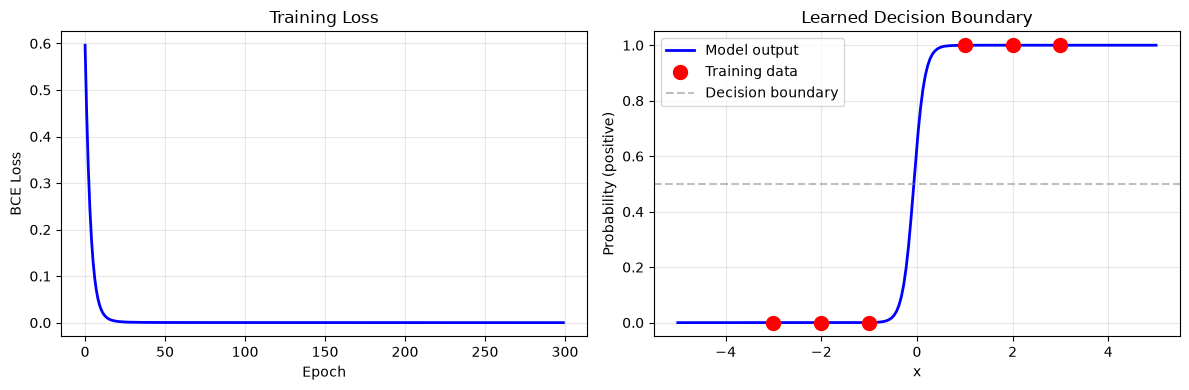

The model learned: negative numbers -> 0, positive numbers -> 1
The S-shaped curve is the sigmoid. The decision boundary is at x = 0.


In [34]:
# Visualize: loss curve + decision boundary
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss curve
axes[0].plot(losses, color='blue', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('BCE Loss')
axes[0].set_title('Training Loss')
axes[0].grid(True, alpha=0.3)

# Decision boundary
x_range = torch.linspace(-5, 5, 200).unsqueeze(1)
with torch.no_grad():
    y_pred = classifier(x_range)

axes[1].plot(x_range.numpy(), y_pred.numpy(), 'b-', linewidth=2, label='Model output')
axes[1].scatter(X.numpy(), y.numpy(), color='red', s=100, zorder=5, label='Training data')
axes[1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Decision boundary')
axes[1].set_xlabel('x')
axes[1].set_ylabel('Probability (positive)')
axes[1].set_title('Learned Decision Boundary')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("The model learned: negative numbers -> 0, positive numbers -> 1")
print("The S-shaped curve is the sigmoid. The decision boundary is at x = 0.")

---
## Part 8: GPU Acceleration

Move tensors and models to GPU for faster training.

```
CPU: your processor (slow for neural networks)
GPU: your graphics card (1000x faster for matrix math)
```

In [36]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using: {device}")

# Move a tensor to GPU
x = torch.randn(3, 3)
print(f"\nBefore .to(device): {x.device}")

x = x.to(device)
print(f"After .to(device):  {x.device}")

# Move a model to GPU
model = nn.Sequential(nn.Linear(10, 5), nn.ReLU(), nn.Linear(5, 1))
model = model.to(device)

# IMPORTANT: data and model must be on the SAME device
input_data = torch.randn(1, 10, device=device)   # create directly on GPU
output = model(input_data)
print(f"\nModel on:  {next(model.parameters()).device}")
print(f"Input on:  {input_data.device}")
print(f"Output on: {output.device}")

print("\nRule: Always move both model and data to the same device.")
print("If no GPU, everything stays on CPU (slower but works fine).")

Using: cpu

Before .to(device): cpu
After .to(device):  cpu

Model on:  cpu
Input on:  cpu
Output on: cpu

Rule: Always move both model and data to the same device.
If no GPU, everything stays on CPU (slower but works fine).


---
## Part 9: Loading Image Data (torchvision)

For GANs, we need image datasets. `torchvision` makes this easy.

In [37]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Download MNIST (handwritten digits)
transform = transforms.Compose([
    transforms.ToTensor(),              # convert image to tensor [0, 1]
    transforms.Normalize([0.5], [0.5])  # shift to [-1, 1]
])

dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

print(f"Dataset size:    {len(dataset)} images")
print(f"Batch size:      64")
print(f"Batches per epoch: {len(dataloader)}")

Dataset size:    60000 images
Batch size:      64
Batches per epoch: 938


In [38]:
# Get one batch and inspect
images, labels = next(iter(dataloader))

print(f"Batch shape:     {images.shape}")
print(f"  -> {images.shape[0]} images")
print(f"  -> {images.shape[1]} channel (grayscale)")
print(f"  -> {images.shape[2]}x{images.shape[3]} pixels")
print(f"Pixel range:     [{images.min():.1f}, {images.max():.1f}]")
print(f"Labels:          {labels[:10].tolist()}")

Batch shape:     torch.Size([64, 1, 28, 28])
  -> 64 images
  -> 1 channel (grayscale)
  -> 28x28 pixels
Pixel range:     [-1.0, 1.0]
Labels:          [1, 6, 0, 2, 2, 4, 5, 8, 9, 3]


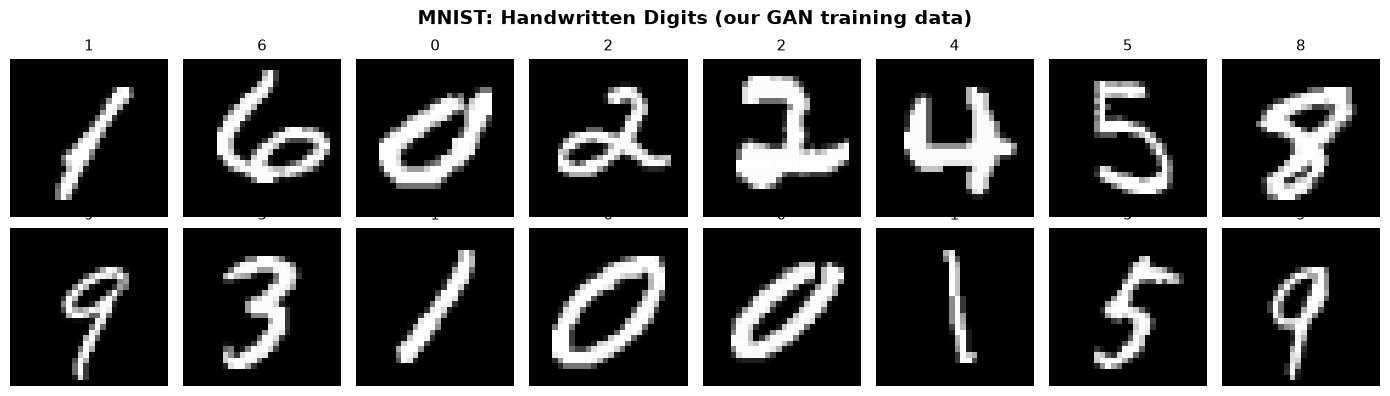

Each image = 28x28 = 784 pixels.
Our GAN will learn to generate images like these from random noise.


In [39]:
# Visualize a batch
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i, 0], cmap='gray')
    ax.set_title(f'{labels[i].item()}', fontsize=11)
    ax.axis('off')

plt.suptitle('MNIST: Handwritten Digits (our GAN training data)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Each image = 28x28 = 784 pixels.")
print("Our GAN will learn to generate images like these from random noise.")

In [40]:
# The DataLoader loop -- how we iterate over the dataset
print("How the training loop works with batches:")
print("=" * 50)

for batch_idx, (images, labels) in enumerate(dataloader):
    if batch_idx < 3:  # just show first 3 batches
        print(f"  Batch {batch_idx}: {images.shape[0]} images, "
              f"labels = {labels[:5].tolist()}...")
    else:
        break

print(f"  ...")
print(f"  Total: {len(dataloader)} batches per epoch")
print(f"\nEach epoch, the DataLoader gives you ALL 60,000 images in batches of 64.")

How the training loop works with batches:
  Batch 0: 64 images, labels = [5, 8, 8, 8, 7]...
  Batch 1: 64 images, labels = [1, 2, 6, 8, 2]...
  Batch 2: 64 images, labels = [9, 2, 7, 4, 4]...
  ...
  Total: 938 batches per epoch

Each epoch, the DataLoader gives you ALL 60,000 images in batches of 64.


---
## Part 10: Putting It All Together — Mini Classifier on MNIST

Let's build a quick classifier: is this digit a 0 or a 1?

This uses everything: DataLoader, nn.Sequential, BCE loss, Adam, the 3-line loop.

In [41]:
# Filter dataset for only 0s and 1s
mask = (dataset.targets == 0) | (dataset.targets == 1)
subset = torch.utils.data.Subset(dataset, mask.nonzero().squeeze())
binary_loader = DataLoader(subset, batch_size=64, shuffle=True)

print(f"Binary dataset: {len(subset)} images (only 0s and 1s)")

# Build classifier
digit_classifier = nn.Sequential(
    nn.Flatten(),                # 1x28x28 --> 784
    nn.Linear(784, 128),
    nn.ReLU(),
    nn.Linear(128, 1),
    nn.Sigmoid()
).to(device)

loss_fn = nn.BCELoss()
optimizer = torch.optim.Adam(digit_classifier.parameters(), lr=0.001)

# Train for 3 epochs
print("\nTraining...")
for epoch in range(1, 4):
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in binary_loader:
        images = images.to(device)
        targets = labels.float().unsqueeze(1).to(device)  # 0.0 or 1.0

        pred = digit_classifier(images)
        loss = loss_fn(pred, targets)

        optimizer.zero_grad()       # 1. Clear
        loss.backward()             # 2. Backprop
        optimizer.step()            # 3. Update

        total_loss += loss.item()
        correct += ((pred > 0.5).float() == targets).sum().item()
        total += targets.size(0)

    acc = correct / total * 100
    print(f"  Epoch {epoch}: loss={total_loss/len(binary_loader):.4f}  accuracy={acc:.1f}%")

print(f"\nThe classifier can tell 0 from 1 with ~{acc:.0f}% accuracy!")

Binary dataset: 12665 images (only 0s and 1s)

Training...
  Epoch 1: loss=0.0236  accuracy=99.2%
  Epoch 2: loss=0.0044  accuracy=99.8%
  Epoch 3: loss=0.0035  accuracy=99.9%

The classifier can tell 0 from 1 with ~100% accuracy!


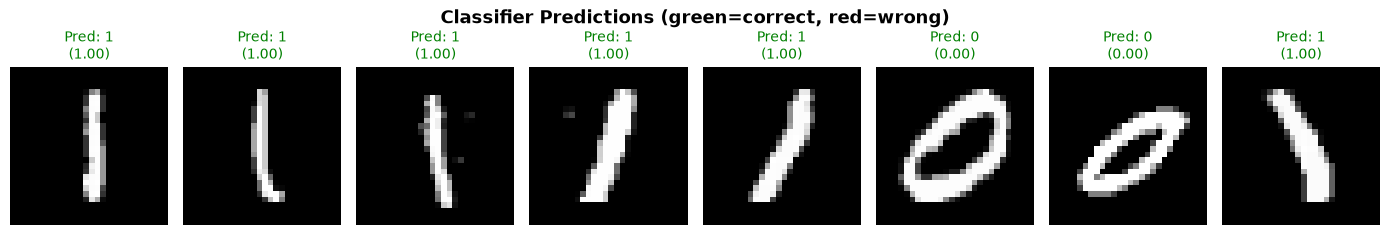

This classifier IS a Discriminator -- it classifies images into two categories.
In a GAN, the categories are 'real' vs 'fake' instead of '0' vs '1'.


In [42]:
# Test on some images
digit_classifier.eval()
test_imgs, test_labels = next(iter(binary_loader))
test_imgs = test_imgs[:8].to(device)

with torch.no_grad():
    preds = digit_classifier(test_imgs).cpu().squeeze()

fig, axes = plt.subplots(1, 8, figsize=(14, 2.5))
for i, ax in enumerate(axes):
    ax.imshow(test_imgs[i, 0].cpu(), cmap='gray')
    pred_label = 1 if preds[i] > 0.5 else 0
    color = 'green' if pred_label == test_labels[i].item() else 'red'
    ax.set_title(f'Pred: {pred_label}\n({preds[i]:.2f})', fontsize=10, color=color)
    ax.axis('off')

plt.suptitle('Classifier Predictions (green=correct, red=wrong)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("This classifier IS a Discriminator -- it classifies images into two categories.")
print("In a GAN, the categories are 'real' vs 'fake' instead of '0' vs '1'.")

---
## Part 11: Key Patterns for GANs

Everything you just learned maps directly to GAN building blocks:

| This lab | In GANs |
|---|---|
| Classifier | The **Discriminator** (real vs fake) |
| `nn.Sequential(Linear, ReLU, ...)` | How we build G and D |
| `nn.BCELoss()` | GAN loss function |
| `torch.optim.Adam(...)` | Optimizer for both G and D |
| `loss.backward()` + `optimizer.step()` | The training loop |
| `model.to(device)` | GPU acceleration |
| `DataLoader` | Batching training images |
| `.detach()` | Will be used to stop gradients in GAN training |

### The `.detach()` preview

In [ ]:
# .detach() will be critical in GANs
# It breaks the gradient chain -- prevents gradients from flowing back

w = torch.tensor(2.0, requires_grad=True)
y = w * 3.0

print(f"y = {y.item()}")
print(f"y.requires_grad = {y.requires_grad}     <-- gradients flow through")

y_detached = y.detach()
print(f"y_detached.requires_grad = {y_detached.requires_grad}  <-- gradient chain BROKEN")

print("\nIn GANs:")
print("  When training D: fake_data = generator(noise).detach()")
print("  --> D learns, but Generator weights DON'T change")
print("  When training G: fake_data = generator(noise)  (no detach)")
print("  --> Gradients flow all the way back to Generator")

---
## Part 12: Summary

| Concept | What you learned | Why it matters for GANs |
|---|---|---|
| Tensors | PyTorch's data containers | All data (images, noise) are tensors |
| `requires_grad` | Enables gradient tracking | Weights need gradients to learn |
| `loss.backward()` | Automatic backpropagation | Computes all gradients in one line |
| `nn.Sequential` | Stack layers to build networks | Build Generator and Discriminator |
| `nn.BCELoss` | Binary classification loss | GAN loss function |
| `Adam` optimizer | Smart weight updates | Standard GAN optimizer |
| `DataLoader` | Batch and shuffle data | Feed images during training |
| `.to(device)` | GPU acceleration | Faster training |
| `.detach()` | Break gradient chain | Control which network learns |

**You now have every PyTorch tool needed to build a GAN. Next lab: we build one.**